<a href="https://colab.research.google.com/github/orutkina/-./blob/main/22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#22

Загрузка датасета

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving archive.zip to archive.zip


In [2]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
df.describe()


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


Датасет содержит информацию о сне, здоровье и образе жизни людей.
В наборе данных присутствуют как числовые, так и категориальные признаки.

In [5]:
df = df.drop('Person ID', axis=1)


In [6]:
df.head()


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [8]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [9]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [10]:
df.isna().sum()


,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0
Heart Rate,0


Пропущенные значения в числовых признаках были заменены медианой,
а в категориальных признаках — наиболее часто встречающимся значением.


In [11]:
y = df['Quality of Sleep']
X = df.drop('Quality of Sleep', axis=1)


In [12]:
y.head()


,Quality of Sleep
0,6
1,6
2,6
3,4
4,4


В качестве целевой переменной выбрано качество сна (Quality of Sleep),
так как данный показатель является числовым и отражает общее состояние здоровья человека.


In [13]:
cat_cols = X.select_dtypes(include='object').columns
cat_cols


Index(['Gender', 'Occupation', 'BMI Category', 'Blood Pressure',
       'Sleep Disorder'],
      dtype='object')

In [15]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')

X_cat = encoder.fit_transform(X[cat_cols])

X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)


In [16]:
X = X.drop(cat_cols, axis=1)
X = pd.concat(
    [X.reset_index(drop=True), X_cat.reset_index(drop=True)],
    axis=1
)


In [17]:
X.head()


,Age,Sleep Duration,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,...,Blood Pressure_130/86,Blood Pressure_131/86,Blood Pressure_132/87,Blood Pressure_135/88,Blood Pressure_135/90,Blood Pressure_139/91,Blood Pressure_140/90,Blood Pressure_140/95,Blood Pressure_142/92,Sleep Disorder_Sleep Apnea
0,27,6.1,42,6,77,4200,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,28,6.2,60,8,75,10000,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,28,6.2,60,8,75,10000,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,28,5.9,30,8,85,3000,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,28,5.9,30,8,85,3000,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
X_scaled[:5]


array([[-1.75309569, -1.29888693, -0.82541823,  0.34702051,  1.6547187 ,
        -1.61958404,  0.9893614 , -0.48406966, -0.45008038, -0.37911857,
        -0.05177804, -0.49246819, -0.07332356, -0.30588765, -0.10397505,
         9.61769203, -0.34606427, -0.24390589, -0.16574839,  1.23572935,
        -0.07332356, -0.07332356, -0.07332356, -0.05177804, -0.07332356,
        -0.36983525, -0.05177804, -0.05177804, -0.45864582, -0.10397505,
        13.6381817 , -0.07332356, -0.0899236 , -0.07332356, -0.6       ,
        -0.07332356, -0.07332356, -0.0899236 , -0.07332356, -0.27894408,
        -0.07332356, -0.10397505, -0.45864582, -0.07332356,  0.50917508],
       [-1.63764266, -1.17303623,  0.03984423,  1.47559156,  1.17047394,
         1.97007745,  0.9893614 ,  2.06581839, -0.45008038, -0.37911857,
        -0.05177804, -0.49246819, -0.07332356, -0.30588765, -0.10397505,
        -0.10397505, -0.34606427, -0.24390589, -0.16574839, -0.80923869,
        -0.07332356, -0.07332356, -0.07332356, -0.

Числовые признаки были стандартизированы с использованием StandardScaler
для улучшения качества обучения модели.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [21]:
X_train.shape, X_test.shape


((299, 45), (75, 45))

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [23]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2: 0.9334621063277331
MSE: 0.10038054501384124


Модель линейной регрессии показала высокое значение коэффициента детерминации
R² = 0.93, что свидетельствует о сильной зависимости между признаками
образа жизни и качеством сна.

Среднеквадратичная ошибка (MSE) составила 0.10, что говорит о высокой
точности предсказаний модели.


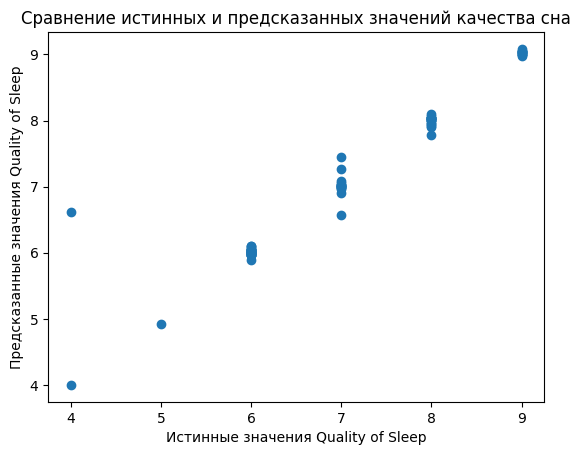

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Истинные значения Quality of Sleep")
plt.ylabel("Предсказанные значения Quality of Sleep")
plt.title("Сравнение истинных и предсказанных значений качества сна")
plt.show()


На графике представлено сравнение истинных и предсказанных значений
качества сна. Большинство точек расположены близко к диагонали,
что подтверждает высокую точность построенной модели.
